<a href="https://colab.research.google.com/github/Reshu2507/hate-speech-detection-text-mining-ml/blob/main/text_mining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv


In [ ]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('stopwords',    quiet=True)
nltk.download('wordnet',      quiet=True)
nltk.download('vader_lexicon',quiet=True)
nltk.download('omw-1.4',      quiet=True)

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

In [ ]:
#PLOT STYLE
plt.rcParams.update({
    'figure.dpi'      : 150,
    'font.family'     : 'DejaVu Sans',
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'axes.titlesize'  : 13,
    'axes.labelsize'  : 11,
    'xtick.labelsize' : 10,
    'ytick.labelsize' : 10,
})

PALETTE    = ['#2E4057', '#E63946']   # blue = non-toxic, red = toxic
SKIP_TOP   = 50
sia        = SentimentIntensityAnalyzer()


In [ ]:
#DATA LOADING & OVERVIEW
df = pd.read_csv('train.csv')
df = df[['comment_text', 'toxic']].dropna().reset_index(drop=True)

print("=" * 55)
print("  DATASET OVERVIEW")
print("=" * 55)
print(f"  Total samples : {len(df):,}")
print(f"  Toxic         : {df['toxic'].sum():,}  ({df['toxic'].mean()*100:.1f}%)")
print(f"  Non-Toxic     : {(df['toxic']==0).sum():,}  ({(1-df['toxic'].mean())*100:.1f}%)")
print("=" * 55)

  DATASET OVERVIEW
  Total samples : 159,571
  Toxic         : 15,294  (9.6%)
  Non-Toxic     : 144,277  (90.4%)


In [ ]:
#TEXT PREPROCESSING
lemmatizer = WordNetLemmatizer()
stop_words  = set(stopwords.words('english'))

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [
        lemmatizer.lemmatize(w)
        for w in text.split()
        if w not in stop_words and len(w) > 2
    ]
    return ' '.join(tokens)

df['clean_text']  = df['comment_text'].apply(clean_text)
df['word_count']  = df['clean_text'].apply(lambda x: len(x.split()))

print("\nSample preprocessed comments:")
print(df[['comment_text', 'clean_text']].head(3).to_string())



Sample preprocessed comments:
                                                                                                                                                                                                                                                                comment_text                                                                                                                                                                clean_text
0  Explanation\nWhy the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27  explanation edits made username hardcore metallica fan reverted werent vandalism closure gas voted new york doll fac please dont remove template talk page since retired
1                                                                                          

In [ ]:
#EXPLORATORY DATA ANALYSIS
def smart_word_filter(word: str, min_len: int = 4,
                      vader_threshold: float = -0.6) -> bool:
    if not word.isalpha():
        return False
    if len(word) < min_len:
        return False
    if sia.polarity_scores(word)['compound'] < vader_threshold:
        return False
    return True

def get_filtered_top_words(subset_df: pd.DataFrame, n: int = 15):
    all_words = ' '.join(subset_df['clean_text']).split()
    filtered  = [
        (w, c) for w, c in Counter(all_words).most_common(500)
        if smart_word_filter(w)
    ][:n]
    if not filtered:
        return [], []
    words, counts = zip(*filtered)
    return list(words), list(counts)


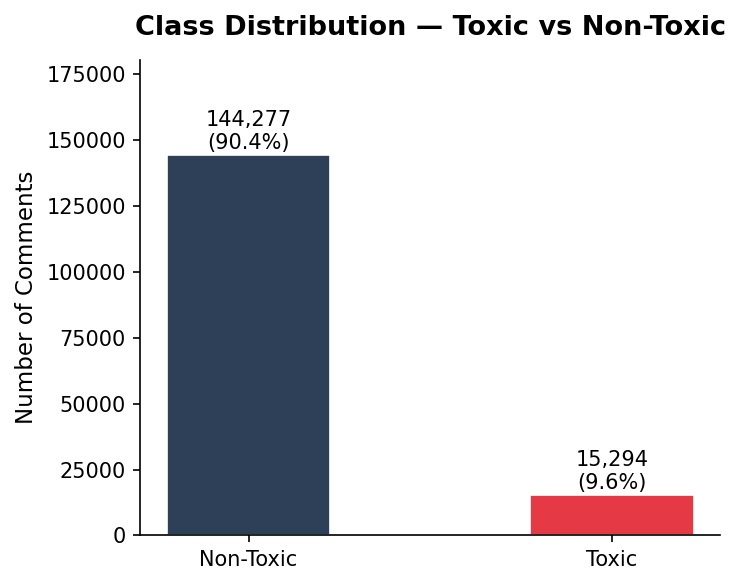

In [ ]:
#Class Distribution
fig, ax = plt.subplots(figsize=(5, 4))
counts  = df['toxic'].value_counts().sort_index()
labels  = ['Non-Toxic', 'Toxic']
bars    = ax.bar(labels, counts.values, color=PALETTE,
                 width=0.45, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 800,
            f'{val:,}\n({val/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=10)

ax.set_title('Class Distribution — Toxic vs Non-Toxic', fontweight='bold', pad=12)
ax.set_ylabel('Number of Comments')
ax.set_ylim(0, counts.max() * 1.25)
plt.tight_layout()
plt.savefig('fig1_class_distribution.png', bbox_inches='tight')
plt.show()

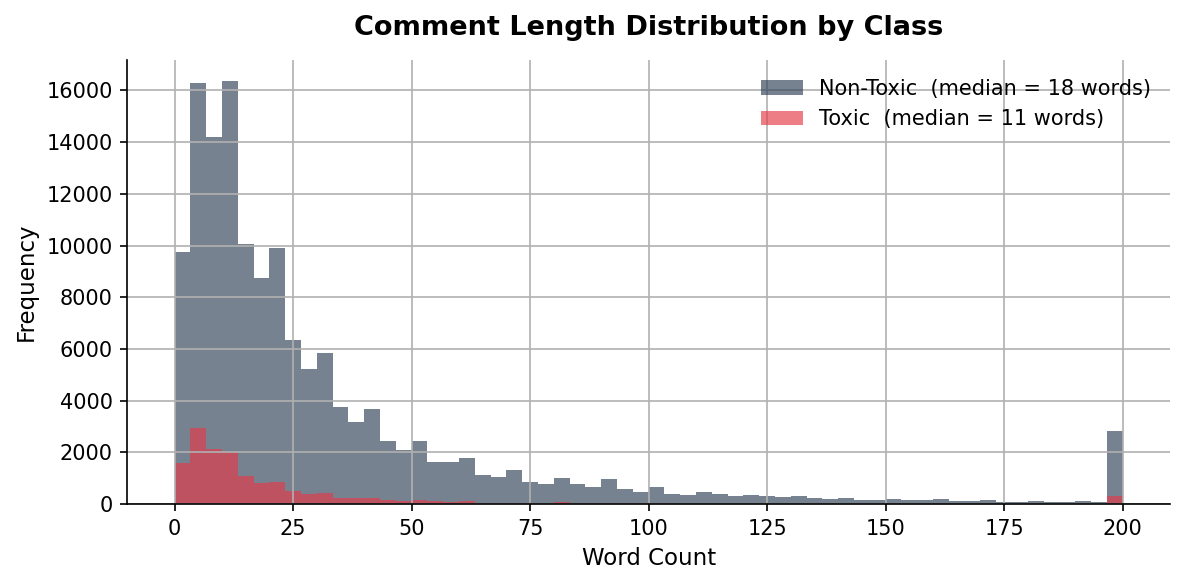

In [ ]:
#Comment Length Distribution
fig, ax = plt.subplots(figsize=(8, 4))
for label, color, name in zip([0, 1], PALETTE, ['Non-Toxic', 'Toxic']):
    subset = df[df['toxic'] == label]['word_count'].clip(upper=200)
    subset.hist(ax=ax, bins=60, alpha=0.65, color=color,
                label=f'{name}  (median = {int(subset.median())} words)')

ax.set_title('Comment Length Distribution by Class', fontweight='bold', pad=12)
ax.set_xlabel('Word Count')
ax.set_ylabel('Frequency')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig('fig2_length_distribution.png', bbox_inches='tight')
plt.show()

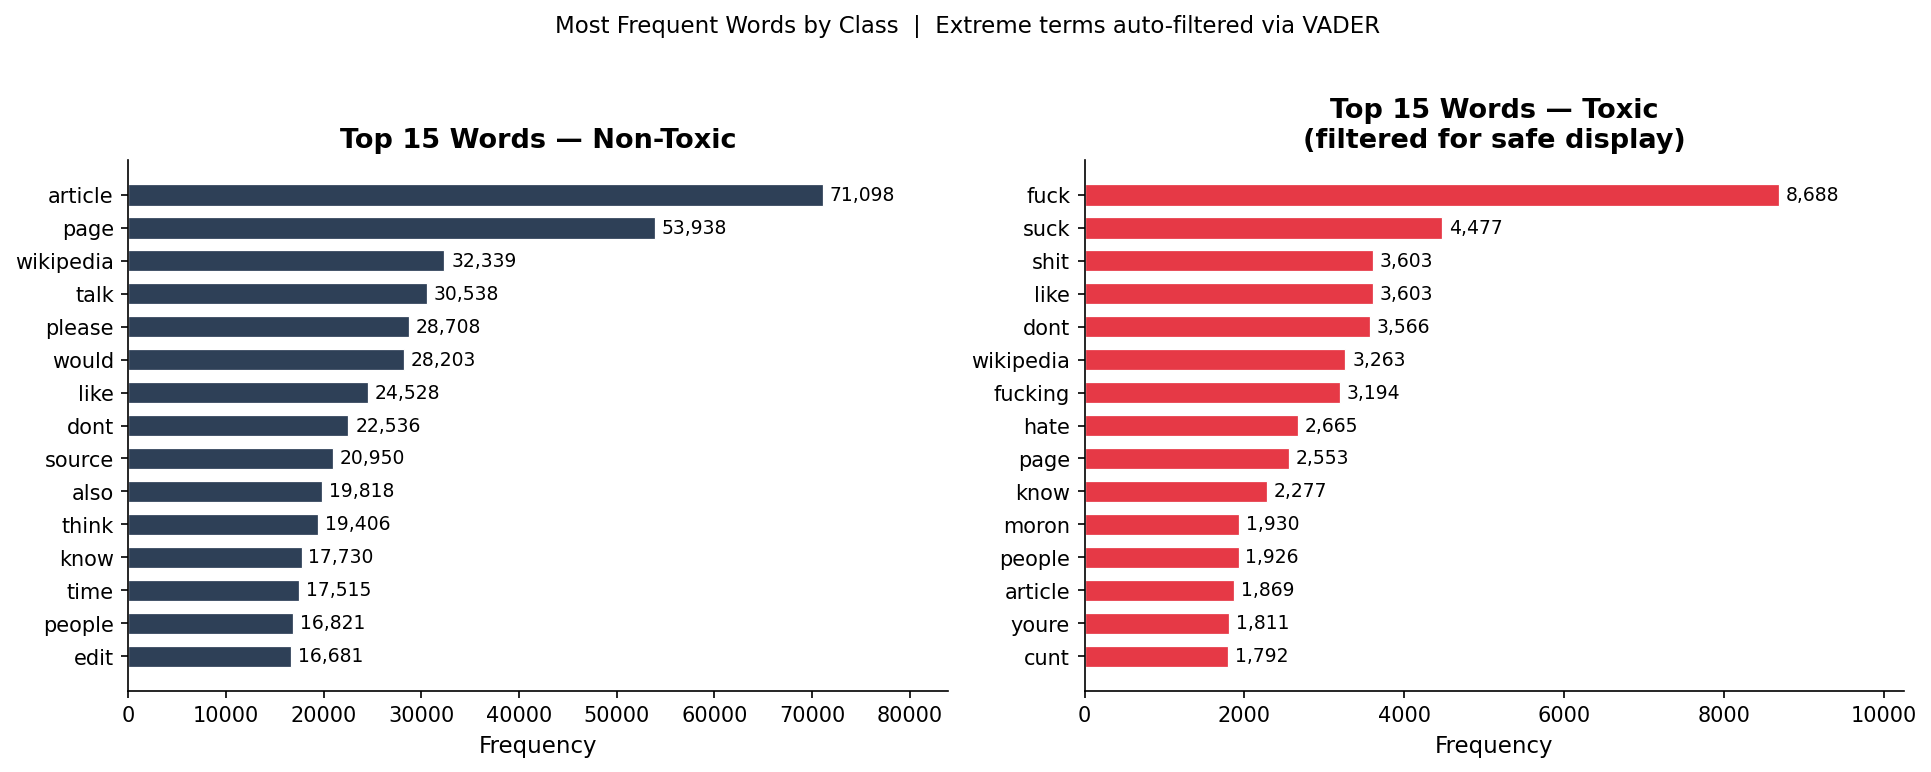

In [ ]:
#Top Words
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, label, color, title in zip(
    axes, [0, 1], PALETTE,
    ['Top 15 Words — Non-Toxic', 'Top 15 Words — Toxic\n(filtered for safe display)']
):
    words, counts = get_filtered_top_words(df[df['toxic'] == label], n=15)
    if not words:
        ax.text(0.5, 0.5, 'No data', ha='center', transform=ax.transAxes)
        continue
    ax.barh(words[::-1], counts[::-1], color=color,
            edgecolor='white', linewidth=0.6, height=0.65)
    for i, (w, c) in enumerate(zip(words[::-1], counts[::-1])):
        ax.text(c + max(counts)*0.01, i, f'{c:,}', va='center', fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Frequency')
    ax.set_xlim(0, max(counts) * 1.18)

plt.suptitle('Most Frequent Words by Class  |  Extreme terms auto-filtered via VADER',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('fig3_top_words.png', bbox_inches='tight')
plt.show()



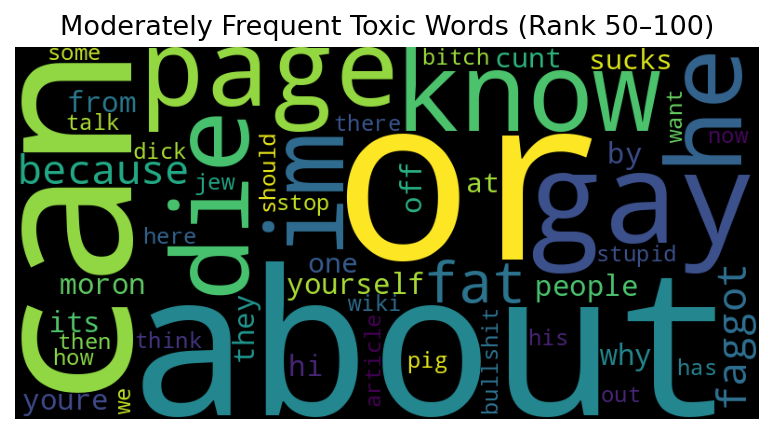

In [ ]:
#Moderately Frequent Toxic Words (Rank 50–100)
toxic_words = " ".join(df[df['toxic']==1]['comment_text']).split()
word_freq = Counter(toxic_words)
sorted_words = word_freq.most_common()
mid_range_words = dict(sorted_words[50:100])
from wordcloud import WordCloud

wc = WordCloud(width=800, height=400,
               background_color='black').generate_from_frequencies(mid_range_words)

plt.imshow(wc)
plt.axis("off")
plt.title("Moderately Frequent Toxic Words (Rank 50–100)")
plt.show()

In [ ]:
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

X = vectorizer.fit_transform(df['comment_text'])
y = df['toxic']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Naive Bayes": MultinomialNB(),
    "SVM": LinearSVC()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, acc, prec, rec, f1])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1"])
print(results_df)

                 Model  Accuracy  Precision    Recall        F1
0  Logistic Regression  0.954661   0.899652  0.592605  0.714539
1          Naive Bayes  0.945104   0.893245  0.484620  0.628341
2                  SVM  0.956979   0.881979  0.635798  0.738924


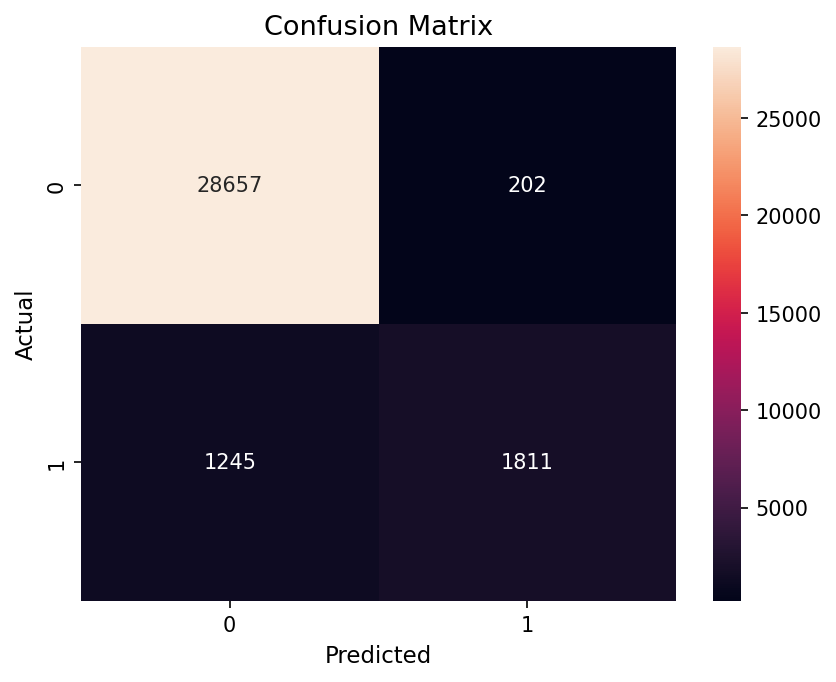

In [ ]:
y_pred = lr_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()